# Proyek Analisis Data: [Bike Dataset Sharing]
- **Nama:** Muhammad Rizky Suryanat
- **Email:** m.rizkysuryanata@gmail.com
- **ID Dicoding:** rizky_suryanata

## Menentukan Pertanyaan Bisnis

Analisis ini menggunakan Bike Sharing Dataset periode 2011–2012. Pertanyaan bisnis dibuat menggunakan prinsip SMART, yaitu Specific, Measurable, Action-Oriented, Relevant, dan Time-Bound.

1. **Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai nilai tertinggi pada hari kerja dan non-hari kerja selama periode 2011–2012?**

   Pertanyaan ini bertujuan mengidentifikasi perbedaan jam sibuk antara hari kerja dan non-hari kerja agar pengelola dapat mengoptimalkan ketersediaan dan redistribusi sepeda.

2. **Seberapa besar perbedaan rata-rata penyewaan sepeda pada setiap kondisi cuaca selama periode 2011–2012, dan kelompok pengguna mana yang paling sensitif terhadap perubahan cuaca?**

   Pertanyaan ini bertujuan mengukur pengaruh kondisi cuaca terhadap pengguna casual dan registered agar pengelola dapat menyusun strategi operasional berdasarkan prakiraan cuaca.

## Import Semua Packages/Library yang Digunakan

In [74]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Mengatur tampilan DataFrame
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

Pada tahap ini, dua berkas dari Bike Sharing Dataset akan dimuat:

- `day.csv`, yang berisi data penyewaan sepeda dalam agregasi harian.
- `hour.csv`, yang berisi data penyewaan sepeda dalam agregasi per jam.

#### Load `day.csv`

In [75]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/data")

day_path = DATA_DIR / "day.csv"

if not day_path.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {day_path}. "
        "Pastikan day.csv berada di dalam folder data."
    )

day_df = pd.read_csv(day_path)

print(f"Jumlah baris day.csv   : {day_df.shape[0]:,}")
print(f"Jumlah kolom day.csv  : {day_df.shape[1]}")

display(day_df.head())

Jumlah baris day.csv   : 731
Jumlah kolom day.csv  : 16


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.34,0.36,0.81,0.16,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.36,0.35,0.70,0.25,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.20,0.19,0.44,0.25,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.20,0.21,0.59,0.16,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.23,0.23,0.44,0.19,82,1518,1600


In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Insight:**

- Dataset `day.csv` memiliki **731 baris** dan **16 kolom**.
- Setiap baris merepresentasikan informasi penyewaan sepeda dalam satu hari.
- Dataset ini akan digunakan untuk menganalisis hubungan antara kondisi cuaca dan jumlah penyewaan harian.

#### Load `hour.csv`

In [77]:
hour_path = DATA_DIR / "hour.csv"

if not hour_path.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {hour_path}. "
        "Pastikan hour.csv berada di dalam folder data."
    )

hour_df = pd.read_csv(hour_path)

print(f"Jumlah baris hour.csv   : {hour_df.shape[0]:,}")
print(f"Jumlah kolom hour.csv  : {hour_df.shape[1]}")

display(hour_df.head())

Jumlah baris hour.csv   : 17,379
Jumlah kolom hour.csv  : 17


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


**Insight:**

- Dataset `hour.csv` memiliki **17.379 baris** dan **17 kolom**.
- Dataset ini memiliki kolom `hr` yang menunjukkan jam pengamatan dari pukul 00.00 hingga 23.00.
- Dataset ini akan digunakan untuk menganalisis pola penyewaan sepeda berdasarkan jam dan jenis hari.

### Assessing Data

Pada tahap assessing data, kualitas kedua dataset diperiksa dengan melihat:

1. Tipe data setiap kolom.
2. Missing value.
3. Data duplikat.
4. Validitas rentang nilai.
5. Konsistensi jumlah pengguna.
6. Kemungkinan outlier pada jumlah penyewaan.

#### Identifying Missing Value and Duplicate Data

In [78]:
def summarize_data_quality(dataframe, dataframe_name):
    """Menampilkan ringkasan kualitas dasar sebuah DataFrame."""

    return pd.DataFrame(
        {
            "dataset": [dataframe_name],
            "total_rows": [len(dataframe)],
            "total_columns": [dataframe.shape[1]],
            "missing_values": [dataframe.isna().sum().sum()],
            "duplicate_rows": [dataframe.duplicated().sum()],
            "duplicate_instant": [dataframe["instant"].duplicated().sum()],
        }
    )


quality_summary = pd.concat(
    [
        summarize_data_quality(day_df, "day.csv"),
        summarize_data_quality(hour_df, "hour.csv"),
    ],
    ignore_index=True,
)

display(quality_summary)

,dataset,total_rows,total_columns,missing_values,duplicate_rows,duplicate_instant
0,day.csv,731,16,0,0,0
1,hour.csv,17379,17,0,0,0


In [79]:
print("Missing value pada day.csv:")
display(day_df.isna().sum().to_frame(name="missing_values"))

print("\nMissing value pada hour.csv:")
display(hour_df.isna().sum().to_frame(name="missing_values"))

Missing value pada day.csv:


,missing_values
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0



Missing value pada hour.csv:


,missing_values
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Steps to Take:**

- Tidak diperlukan proses imputasi karena tidak ditemukan missing value.
- Tidak diperlukan penghapusan data duplikat karena tidak ditemukan baris maupun nilai `instant` yang terduplikasi.
- Pemeriksaan dilanjutkan pada tipe data, rentang nilai, dan konsistensi antarkolom.

**Insight:**

- Kedua dataset tidak memiliki missing value.
- Kedua dataset tidak memiliki data duplikat.
- Nilai `instant` juga bersifat unik pada setiap dataset.

#### Identifying Data Type Problem

In [80]:
print("Tipe data day.csv:")
display(day_df.dtypes.to_frame(name="data_type"))

print("\nTipe data hour.csv:")
display(hour_df.dtypes.to_frame(name="data_type"))

Tipe data day.csv:


,data_type
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64



Tipe data hour.csv:


,data_type
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


**Steps to Take:**

- Kolom `dteday` masih memiliki tipe data `object`, sehingga perlu dikonversi menjadi `datetime`.
- Kolom kategori seperti `season`, `weekday`, `weathersit`, dan `yr` masih berbentuk kode numerik sehingga perlu diberikan label yang lebih informatif.
- Kolom `temp`, `atemp`, `hum`, dan `windspeed` masih berbentuk nilai normalisasi sehingga perlu dikonversi ke satuan yang lebih mudah dipahami.

**Insight:**

- Masalah utama yang ditemukan bukan missing value atau duplikasi, tetapi ketidaksesuaian tipe data dan rendahnya interpretabilitas beberapa kolom.

#### Identifying Invalid and Inconsistent Values

In [81]:
def validate_dataset(dataframe, include_hour=False):
    """Menghitung jumlah nilai yang tidak sesuai dengan aturan dataset."""

    validation_result = {
        "season_di_luar_1_4": (~dataframe["season"].isin([1, 2, 3, 4])).sum(),
        "year_di_luar_0_1": (~dataframe["yr"].isin([0, 1])).sum(),
        "month_di_luar_1_12": (~dataframe["mnth"].between(1, 12)).sum(),
        "holiday_di_luar_0_1": (~dataframe["holiday"].isin([0, 1])).sum(),
        "weekday_di_luar_0_6": (~dataframe["weekday"].between(0, 6)).sum(),
        "workingday_di_luar_0_1": (
            ~dataframe["workingday"].isin([0, 1])
        ).sum(),
        "weather_di_luar_1_4": (
            ~dataframe["weathersit"].isin([1, 2, 3, 4])
        ).sum(),
        "negative_casual": (dataframe["casual"] < 0).sum(),
        "negative_registered": (dataframe["registered"] < 0).sum(),
        "negative_cnt": (dataframe["cnt"] < 0).sum(),
        "cnt_tidak_konsisten": (
            dataframe["casual"] + dataframe["registered"]
            != dataframe["cnt"]
        ).sum(),
    }

    if include_hour:
        validation_result["hour_di_luar_0_23"] = (
            ~dataframe["hr"].between(0, 23)
        ).sum()

    return validation_result


day_validation = pd.Series(
    validate_dataset(day_df),
    name="day.csv",
)

hour_validation = pd.Series(
    validate_dataset(hour_df, include_hour=True),
    name="hour.csv",
)

validation_summary = pd.concat(
    [day_validation, hour_validation],
    axis=1,
).fillna(0).astype(int)

display(validation_summary)

,day.csv,hour.csv
season_di_luar_1_4,0,0
year_di_luar_0_1,0,0
month_di_luar_1_12,0,0
holiday_di_luar_0_1,0,0
weekday_di_luar_0_6,0,0
workingday_di_luar_0_1,0,0
weather_di_luar_1_4,0,0
negative_casual,0,0
negative_registered,0,0
negative_cnt,0,0


In [82]:
print("Rentang nilai numerik day.csv:")
display(
    day_df[
        [
            "temp",
            "atemp",
            "hum",
            "windspeed",
            "casual",
            "registered",
            "cnt",
        ]
    ].describe()
)

print("\nRentang nilai numerik hour.csv:")
display(
    hour_df[
        [
            "hr",
            "temp",
            "atemp",
            "hum",
            "windspeed",
            "casual",
            "registered",
            "cnt",
        ]
    ].describe()
)

Rentang nilai numerik day.csv:


,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.00,731.00,731.00,731.00,731.00,731.00,731.00
mean,0.50,0.47,0.63,0.19,848.18,"3,656.17","4,504.35"
std,0.18,0.16,0.14,0.08,686.62,"1,560.26","1,937.21"
min,0.06,0.08,0.00,0.02,2.00,20.00,22.00
25%,0.34,0.34,0.52,0.13,315.50,"2,497.00","3,152.00"
50%,0.50,0.49,0.63,0.18,713.00,"3,662.00","4,548.00"
75%,0.66,0.61,0.73,0.23,"1,096.00","4,776.50","5,956.00"
max,0.86,0.84,0.97,0.51,"3,410.00","6,946.00","8,714.00"



Rentang nilai numerik hour.csv:


,hr,temp,atemp,hum,windspeed,casual,registered,cnt
count,"17,379.00","17,379.00","17,379.00","17,379.00","17,379.00","17,379.00","17,379.00","17,379.00"
mean,11.55,0.50,0.48,0.63,0.19,35.68,153.79,189.46
std,6.91,0.19,0.17,0.19,0.12,49.31,151.36,181.39
min,0.00,0.02,0.00,0.00,0.00,0.00,0.00,1.00
25%,6.00,0.34,0.33,0.48,0.10,4.00,34.00,40.00
50%,12.00,0.50,0.48,0.63,0.19,17.00,115.00,142.00
75%,18.00,0.66,0.62,0.78,0.25,48.00,220.00,281.00
max,23.00,1.00,1.00,1.00,0.85,367.00,886.00,977.00


**Steps to Take:**

- Tidak diperlukan koreksi nilai kategori karena seluruh kode berada dalam rentang yang valid.
- Tidak ditemukan jumlah pengguna bernilai negatif.
- Tidak ditemukan perbedaan antara `cnt` dengan hasil penjumlahan `casual` dan `registered`.
- Nilai cuaca yang masih dinormalisasi akan dikonversi pada tahap cleaning.

**Insight:**

- Seluruh kategori memiliki kode yang valid.
- Kolom `cnt` konsisten dengan rumus:

  `cnt = casual + registered`

- Tidak ditemukan jumlah penyewaan bernilai negatif.

#### Identifying Outliers in Rental Count

In [83]:
def calculate_iqr_outliers(dataframe, column, dataset_name):
    """Mengidentifikasi outlier menggunakan metode IQR."""

    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (dataframe[column] < lower_bound)
        | (dataframe[column] > upper_bound)
    )

    return {
        "dataset": dataset_name,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_mask.sum(),
        "outlier_percentage": outlier_mask.mean() * 100,
    }


outlier_summary = pd.DataFrame(
    [
        calculate_iqr_outliers(day_df, "cnt", "day.csv"),
        calculate_iqr_outliers(hour_df, "cnt", "hour.csv"),
    ]
)

display(outlier_summary.round(2))

,dataset,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,day.csv,"3,152.00","5,956.00","2,804.00","-1,054.00","10,162.00",0,0.00
1,hour.csv,40.00,281.00,241.00,-321.50,642.50,505,2.91


**Steps to Take:**

- Tidak ditemukan outlier pada jumlah penyewaan harian berdasarkan metode IQR.
- Pada data per jam ditemukan sejumlah observasi di atas batas IQR.
- Outlier pada data per jam tidak langsung dihapus karena kemungkinan merepresentasikan jam sibuk dengan permintaan yang memang tinggi.
- Observasi tersebut tetap dipertahankan agar pola permintaan pada jam sibuk tidak hilang dari analisis.

**Insight:**

- `day.csv` tidak memiliki outlier pada kolom `cnt` berdasarkan metode IQR.
- `hour.csv` memiliki sekitar **505 observasi** yang teridentifikasi sebagai outlier.
- Nilai tersebut masih masuk akal secara operasional karena jumlah penyewaan dapat meningkat tajam pada jam berangkat dan pulang kerja.

### Cleaning Data

Proses cleaning yang dilakukan meliputi:

1. Mengubah tipe data tanggal.
2. Menambahkan label kategori.
3. Mengubah nilai cuaca yang dinormalisasi ke satuan aktual.
4. Menambahkan kategori jenis hari.
5. Menghapus kolom indeks yang tidak diperlukan.

#### Fixing Date Data Type Problem

In [84]:
day_clean = day_df.copy()
hour_clean = hour_df.copy()

day_clean["dteday"] = pd.to_datetime(
    day_clean["dteday"],
    errors="raise",
)

hour_clean["dteday"] = pd.to_datetime(
    hour_clean["dteday"],
    errors="raise",
)

print("Tipe data dteday pada day_clean:")
print(day_clean["dteday"].dtype)

print("\nTipe data dteday pada hour_clean:")
print(hour_clean["dteday"].dtype)

Tipe data dteday pada day_clean:
datetime64[ns]

Tipe data dteday pada hour_clean:
datetime64[ns]


**Insight:**

- Kolom `dteday` pada kedua dataset telah dikonversi dari `object` menjadi `datetime64`.
- Konversi ini memungkinkan proses filtering, grouping, dan visualisasi berdasarkan periode waktu dilakukan dengan benar.

#### Fixing Categorical Representation Problem

In [85]:
season_mapping = {
    1: "Musim Semi",
    2: "Musim Panas",
    3: "Musim Gugur",
    4: "Musim Dingin",
}

year_mapping = {
    0: 2011,
    1: 2012,
}

weekday_mapping = {
    0: "Minggu",
    1: "Senin",
    2: "Selasa",
    3: "Rabu",
    4: "Kamis",
    5: "Jumat",
    6: "Sabtu",
}

weather_mapping = {
    1: "Cerah/Berawan Sebagian",
    2: "Berkabut/Berawan",
    3: "Hujan/Salju Ringan",
    4: "Hujan/Salju Lebat",
}


def add_category_labels(dataframe):
    """Menambahkan label yang mudah dibaca untuk kolom kategori."""

    cleaned_dataframe = dataframe.copy()

    cleaned_dataframe["year"] = cleaned_dataframe["yr"].map(
        year_mapping
    )

    cleaned_dataframe["season_label"] = cleaned_dataframe["season"].map(
        season_mapping
    )

    cleaned_dataframe["weekday_label"] = cleaned_dataframe["weekday"].map(
        weekday_mapping
    )

    cleaned_dataframe["weather_label"] = cleaned_dataframe[
        "weathersit"
    ].map(weather_mapping)

    cleaned_dataframe["day_type"] = np.where(
        cleaned_dataframe["workingday"].eq(1),
        "Hari Kerja",
        "Non-Hari Kerja",
    )

    return cleaned_dataframe


day_clean = add_category_labels(day_clean)
hour_clean = add_category_labels(hour_clean)

display(
    day_clean[
        [
            "dteday",
            "year",
            "season_label",
            "weekday_label",
            "weather_label",
            "day_type",
        ]
    ].head()
)

,dteday,year,season_label,weekday_label,weather_label,day_type
0,2011-01-01,2011,Musim Semi,Sabtu,Berkabut/Berawan,Non-Hari Kerja
1,2011-01-02,2011,Musim Semi,Minggu,Berkabut/Berawan,Non-Hari Kerja
2,2011-01-03,2011,Musim Semi,Senin,Cerah/Berawan Sebagian,Hari Kerja
3,2011-01-04,2011,Musim Semi,Selasa,Cerah/Berawan Sebagian,Hari Kerja
4,2011-01-05,2011,Musim Semi,Rabu,Cerah/Berawan Sebagian,Hari Kerja


**Insight:**

- Kode kategori telah diubah menjadi label yang lebih mudah dipahami.
- Kolom `day_type` membedakan hari kerja dengan non-hari kerja.
- Non-hari kerja mencakup akhir pekan dan hari libur.

#### Fixing Normalized Weather Values

In [86]:
def denormalize_weather_columns(dataframe):
    """Mengubah variabel cuaca ke satuan yang lebih informatif."""

    cleaned_dataframe = dataframe.copy()

    cleaned_dataframe["temp_c"] = (
        cleaned_dataframe["temp"] * 41
    )

    cleaned_dataframe["atemp_c"] = (
        cleaned_dataframe["atemp"] * 50
    )

    cleaned_dataframe["humidity_pct"] = (
        cleaned_dataframe["hum"] * 100
    )

    cleaned_dataframe["windspeed_kmh"] = (
        cleaned_dataframe["windspeed"] * 67
    )

    return cleaned_dataframe


day_clean = denormalize_weather_columns(day_clean)
hour_clean = denormalize_weather_columns(hour_clean)

display(
    day_clean[
        [
            "temp",
            "temp_c",
            "atemp",
            "atemp_c",
            "hum",
            "humidity_pct",
            "windspeed",
            "windspeed_kmh",
        ]
    ].head()
)

,temp,temp_c,atemp,atemp_c,hum,humidity_pct,windspeed,windspeed_kmh
0,0.34,14.11,0.36,18.18,0.81,80.58,0.16,10.75
1,0.36,14.90,0.35,17.69,0.70,69.61,0.25,16.65
2,0.20,8.05,0.19,9.47,0.44,43.73,0.25,16.64
3,0.20,8.20,0.21,10.61,0.59,59.04,0.16,10.74
4,0.23,9.31,0.23,11.46,0.44,43.70,0.19,12.52


**Insight:**

- `temp_c` menunjukkan suhu aktual dalam derajat Celsius.
- `atemp_c` menunjukkan suhu yang dirasakan dalam derajat Celsius.
- `humidity_pct` menunjukkan kelembapan dalam persen.
- `windspeed_kmh` menunjukkan kecepatan angin dalam km/jam.
- Kolom hasil konversi lebih mudah digunakan untuk interpretasi bisnis.

#### Removing Unnecessary Index Column

In [87]:
day_clean.drop(
    columns=["instant"],
    inplace=True,
)

hour_clean.drop(
    columns=["instant"],
    inplace=True,
)

print("Ukuran day_clean :", day_clean.shape)
print("Ukuran hour_clean:", hour_clean.shape)

Ukuran day_clean : (731, 24)
Ukuran hour_clean: (17379, 25)


In [88]:
cleaning_validation = pd.DataFrame(
    {
        "dataset": ["day_clean", "hour_clean"],
        "missing_values": [
            day_clean.isna().sum().sum(),
            hour_clean.isna().sum().sum(),
        ],
        "duplicate_rows": [
            day_clean.duplicated().sum(),
            hour_clean.duplicated().sum(),
        ],
        "minimum_cnt": [
            day_clean["cnt"].min(),
            hour_clean["cnt"].min(),
        ],
        "maximum_cnt": [
            day_clean["cnt"].max(),
            hour_clean["cnt"].max(),
        ],
    }
)

display(cleaning_validation)

,dataset,missing_values,duplicate_rows,minimum_cnt,maximum_cnt
0,day_clean,0,0,22,8714
1,hour_clean,0,0,1,977


**Insight:**

- Kolom `instant` dihapus karena hanya berfungsi sebagai nomor urut dan tidak memiliki nilai analitis.
- Setelah proses cleaning, tidak ditemukan missing value maupun data duplikat.
- Data siap digunakan untuk proses Exploratory Data Analysis.

## Exploratory Data Analysis (EDA)

### Explore Descriptive Statistics of Bike Rentals

In [89]:
daily_rental_summary = day_clean[
    ["casual", "registered", "cnt"]
].describe().T

hourly_rental_summary = hour_clean[
    ["casual", "registered", "cnt"]
].describe().T

print("Statistik penyewaan harian:")
display(daily_rental_summary)

print("\nStatistik penyewaan per jam:")
display(hourly_rental_summary)

Statistik penyewaan harian:


,count,mean,std,min,25%,50%,75%,max
casual,731.00,848.18,686.62,2.00,315.50,713.00,"1,096.00","3,410.00"
registered,731.00,"3,656.17","1,560.26",20.00,"2,497.00","3,662.00","4,776.50","6,946.00"
cnt,731.00,"4,504.35","1,937.21",22.00,"3,152.00","4,548.00","5,956.00","8,714.00"



Statistik penyewaan per jam:


,count,mean,std,min,25%,50%,75%,max
casual,"17,379.00",35.68,49.31,0.00,4.00,17.00,48.00,367.00
registered,"17,379.00",153.79,151.36,0.00,34.00,115.00,220.00,886.00
cnt,"17,379.00",189.46,181.39,1.00,40.00,142.00,281.00,977.00


In [90]:
total_daily_rentals = day_clean["cnt"].sum()
total_casual_rentals = day_clean["casual"].sum()
total_registered_rentals = day_clean["registered"].sum()

user_composition = pd.DataFrame(
    {
        "user_type": ["Casual", "Registered"],
        "total_rentals": [
            total_casual_rentals,
            total_registered_rentals,
        ],
    }
)

user_composition["percentage"] = (
    user_composition["total_rentals"]
    / total_daily_rentals
    * 100
)

display(user_composition.round(2))

,user_type,total_rentals,percentage
0,Casual,620017,18.83
1,Registered,2672662,81.17


**Insight:**

- Jumlah penyewaan harian memiliki variasi yang cukup besar, menunjukkan adanya perbedaan permintaan berdasarkan waktu dan kondisi lingkungan.
- Pengguna registered memberikan kontribusi terbesar terhadap total penyewaan.
- Hal ini menunjukkan bahwa layanan bike sharing lebih banyak digunakan oleh pelanggan terdaftar dibandingkan pelanggan casual.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

### Explore Hourly Rental Pattern by Day Type

Analisis ini digunakan untuk menjawab pertanyaan bisnis pertama, yaitu mengidentifikasi jam dengan rata-rata penyewaan tertinggi pada hari kerja dan non-hari kerja.

In [91]:
hourly_pattern = (
    hour_clean.groupby(
        ["day_type", "hr"],
        as_index=False,
    )
    .agg(
        average_total_rentals=("cnt", "mean"),
        average_casual_rentals=("casual", "mean"),
        average_registered_rentals=("registered", "mean"),
        observation_count=("cnt", "size"),
    )
)

display(hourly_pattern.head(10))

,day_type,hr,average_total_rentals,average_casual_rentals,average_registered_rentals,observation_count
0,Hari Kerja,0,36.79,7.15,29.64,496
1,Hari Kerja,1,16.55,3.71,12.84,494
2,Hari Kerja,2,8.68,2.14,6.55,487
3,Hari Kerja,3,4.94,0.91,4.03,470
4,Hari Kerja,4,5.43,0.77,4.66,470
5,Hari Kerja,5,24.91,1.27,23.64,495
6,Hari Kerja,6,102.50,4.32,98.18,496
7,Hari Kerja,7,290.61,12.20,278.42,496
8,Hari Kerja,8,477.01,22.26,454.74,496
9,Hari Kerja,9,241.52,24.31,217.21,496


In [92]:
peak_hour_by_day_type = hourly_pattern.loc[
    hourly_pattern.groupby("day_type")[
        "average_total_rentals"
    ].idxmax()
].copy()

peak_hour_by_day_type = peak_hour_by_day_type.sort_values(
    "day_type"
).reset_index(drop=True)

display(
    peak_hour_by_day_type[
        [
            "day_type",
            "hr",
            "average_total_rentals",
            "average_casual_rentals",
            "average_registered_rentals",
        ]
    ].round(2)
)

,day_type,hr,average_total_rentals,average_casual_rentals,average_registered_rentals
0,Hari Kerja,17,525.29,56.90,468.39
1,Non-Hari Kerja,13,372.73,136.42,236.31


In [93]:
top_five_hours = (
    hourly_pattern.sort_values(
        ["day_type", "average_total_rentals"],
        ascending=[True, False],
    )
    .groupby("day_type", as_index=False)
    .head(5)
)

display(
    top_five_hours[
        [
            "day_type",
            "hr",
            "average_total_rentals",
        ]
    ].round(2)
)

,day_type,hr,average_total_rentals
17,Hari Kerja,17,525.29
18,Hari Kerja,18,492.23
8,Hari Kerja,8,477.01
19,Hari Kerja,19,348.40
16,Hari Kerja,16,293.12
37,Non-Hari Kerja,13,372.73
36,Non-Hari Kerja,12,366.26
38,Non-Hari Kerja,14,364.65
39,Non-Hari Kerja,15,358.81
40,Non-Hari Kerja,16,352.73


**Insight:**

- Pada **hari kerja**, rata-rata penyewaan tertinggi terjadi pada pukul **17.00**, yaitu sekitar **525 penyewaan per jam**.
- Permintaan tinggi pada hari kerja juga terlihat pada pukul **08.00** dan **18.00**.
- Pola tersebut berkaitan dengan jam keberangkatan dan kepulangan pekerja.
- Pada **non-hari kerja**, rata-rata penyewaan tertinggi terjadi pada pukul **13.00**, yaitu sekitar **373 penyewaan per jam**.
- Pada non-hari kerja, permintaan tinggi tersebar dari siang hingga sore dan tidak membentuk dua puncak seperti pada hari kerja.

### Pertanyaan 2:

### Explore Rental Pattern by Weather Condition

Analisis ini digunakan untuk menjawab pertanyaan bisnis kedua, yaitu mengukur perubahan rata-rata penyewaan pada setiap kondisi cuaca dan menentukan kelompok pengguna yang paling sensitif terhadap cuaca.

In [94]:
weather_order = [
    "Cerah/Berawan Sebagian",
    "Berkabut/Berawan",
    "Hujan/Salju Ringan",
    "Hujan/Salju Lebat",
]

weather_summary = (
    day_clean.groupby(
        "weather_label",
        as_index=False,
    )
    .agg(
        average_total_rentals=("cnt", "mean"),
        median_total_rentals=("cnt", "median"),
        average_casual_rentals=("casual", "mean"),
        average_registered_rentals=("registered", "mean"),
        observation_days=("cnt", "size"),
    )
    .set_index("weather_label")
    .reindex(weather_order)
    .dropna(how="all")
    .reset_index()
)

display(weather_summary.round(2))

,weather_label,average_total_rentals,median_total_rentals,average_casual_rentals,average_registered_rentals,observation_days
0,Cerah/Berawan Sebagian,"4,876.79","4,844.00",964.03,"3,912.76",463.00
1,Berkabut/Berawan,"4,035.86","4,040.00",687.35,"3,348.51",247.00
2,Hujan/Salju Ringan,"1,803.29","1,817.00",185.48,"1,617.81",21.00


In [95]:
clear_weather_row = weather_summary.loc[
    weather_summary["weather_label"]
    == "Cerah/Berawan Sebagian"
].iloc[0]

clear_total = clear_weather_row["average_total_rentals"]
clear_casual = clear_weather_row["average_casual_rentals"]
clear_registered = clear_weather_row["average_registered_rentals"]

weather_summary["total_decline_vs_clear_pct"] = (
    1
    - weather_summary["average_total_rentals"]
    / clear_total
) * 100

weather_summary["casual_decline_vs_clear_pct"] = (
    1
    - weather_summary["average_casual_rentals"]
    / clear_casual
) * 100

weather_summary["registered_decline_vs_clear_pct"] = (
    1
    - weather_summary["average_registered_rentals"]
    / clear_registered
) * 100

weather_summary["casual_share_pct"] = (
    weather_summary["average_casual_rentals"]
    / weather_summary["average_total_rentals"]
    * 100
)

display(
    weather_summary[
        [
            "weather_label",
            "average_total_rentals",
            "total_decline_vs_clear_pct",
            "casual_decline_vs_clear_pct",
            "registered_decline_vs_clear_pct",
            "casual_share_pct",
        ]
    ].round(2)
)

,weather_label,average_total_rentals,total_decline_vs_clear_pct,casual_decline_vs_clear_pct,registered_decline_vs_clear_pct,casual_share_pct
0,Cerah/Berawan Sebagian,"4,876.79",0.00,0.00,0.00,19.77
1,Berkabut/Berawan,"4,035.86",17.24,28.70,14.42,17.03
2,Hujan/Salju Ringan,"1,803.29",63.02,80.76,58.65,10.29


**Insight:**

- Pada cuaca cerah atau berawan sebagian, rata-rata penyewaan mencapai sekitar **4.877 penyewaan per hari**.
- Pada kondisi berkabut atau berawan, rata-rata penyewaan turun sekitar **17,2%** dibandingkan cuaca cerah.
- Pada kondisi hujan atau salju ringan, rata-rata penyewaan turun sekitar **63,0%**.
- Pada kondisi berkabut atau berawan, rata-rata pengguna casual turun sekitar **28,7%**, sedangkan pengguna registered turun sekitar **14,4%**.
- Pada hujan atau salju ringan, pengguna casual turun sekitar **80,8%**, sedangkan pengguna registered turun sekitar **58,7%**.
- Pengguna casual lebih sensitif terhadap perubahan cuaca dibandingkan pengguna registered.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

**Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai nilai tertinggi pada hari kerja dan non-hari kerja selama periode 2011–2012?**

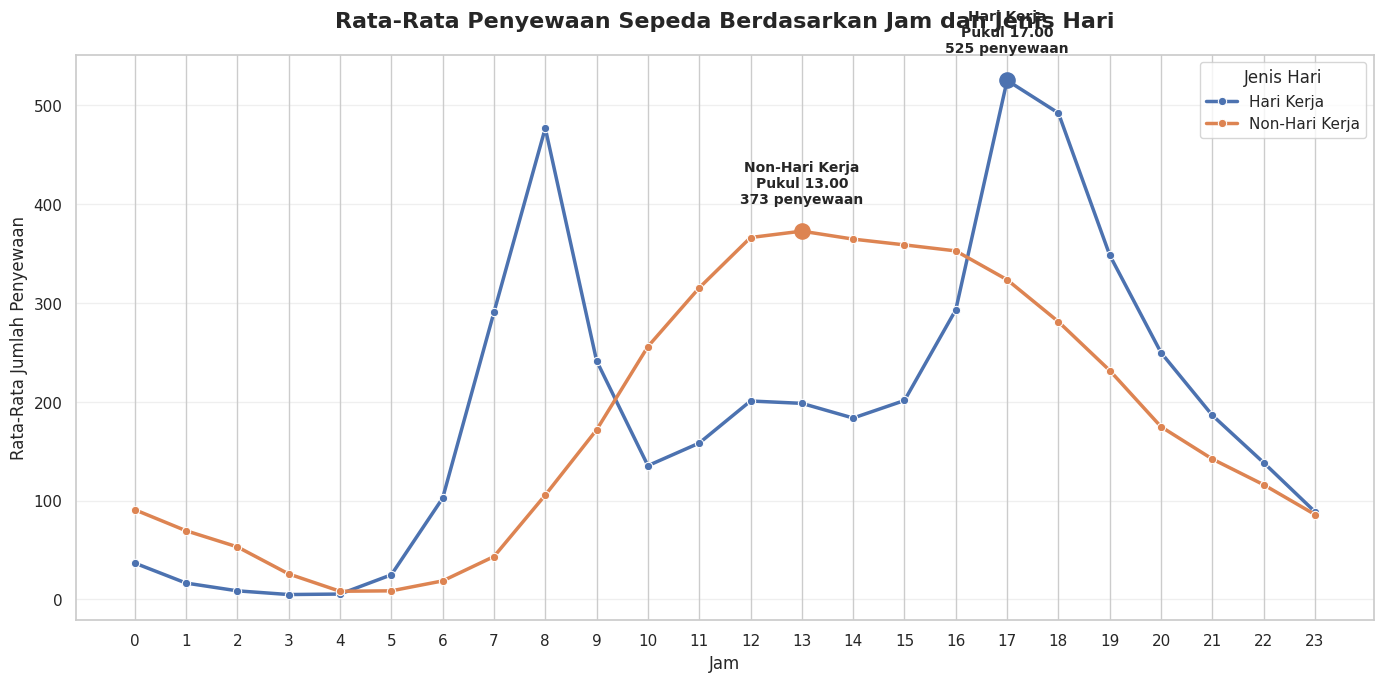

In [96]:
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=hourly_pattern,
    x="hr",
    y="average_total_rentals",
    hue="day_type",
    marker="o",
    linewidth=2.5,
)

for _, peak_row in peak_hour_by_day_type.iterrows():
    ax.scatter(
        peak_row["hr"],
        peak_row["average_total_rentals"],
        s=120,
        zorder=5,
    )

    ax.annotate(
        (
            f'{peak_row["day_type"]}\n'
            f'Pukul {int(peak_row["hr"]):02d}.00\n'
            f'{peak_row["average_total_rentals"]:.0f} penyewaan'
        ),
        xy=(
            peak_row["hr"],
            peak_row["average_total_rentals"],
        ),
        xytext=(0, 20),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "Rata-Rata Penyewaan Sepeda Berdasarkan Jam dan Jenis Hari",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

plt.xlabel("Jam")
plt.ylabel("Rata-Rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Jenis Hari")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

- Hari kerja membentuk dua pola jam sibuk, yaitu sekitar pukul 08.00 dan 17.00–18.00.
- Puncak tertinggi pada hari kerja terjadi pukul 17.00.
- Non-hari kerja memiliki pola yang lebih landai dengan permintaan tertinggi pada pukul 13.00.
- Perbedaan ini menunjukkan bahwa strategi penyediaan sepeda perlu dibedakan antara hari kerja dan non-hari kerja.

### Pertanyaan 2:

**Seberapa besar perbedaan rata-rata penyewaan sepeda pada setiap kondisi cuaca selama periode 2011–2012, dan kelompok pengguna mana yang paling sensitif terhadap perubahan cuaca?**

#### Rata-Rata Total Penyewaan Berdasarkan Kondisi Cuaca

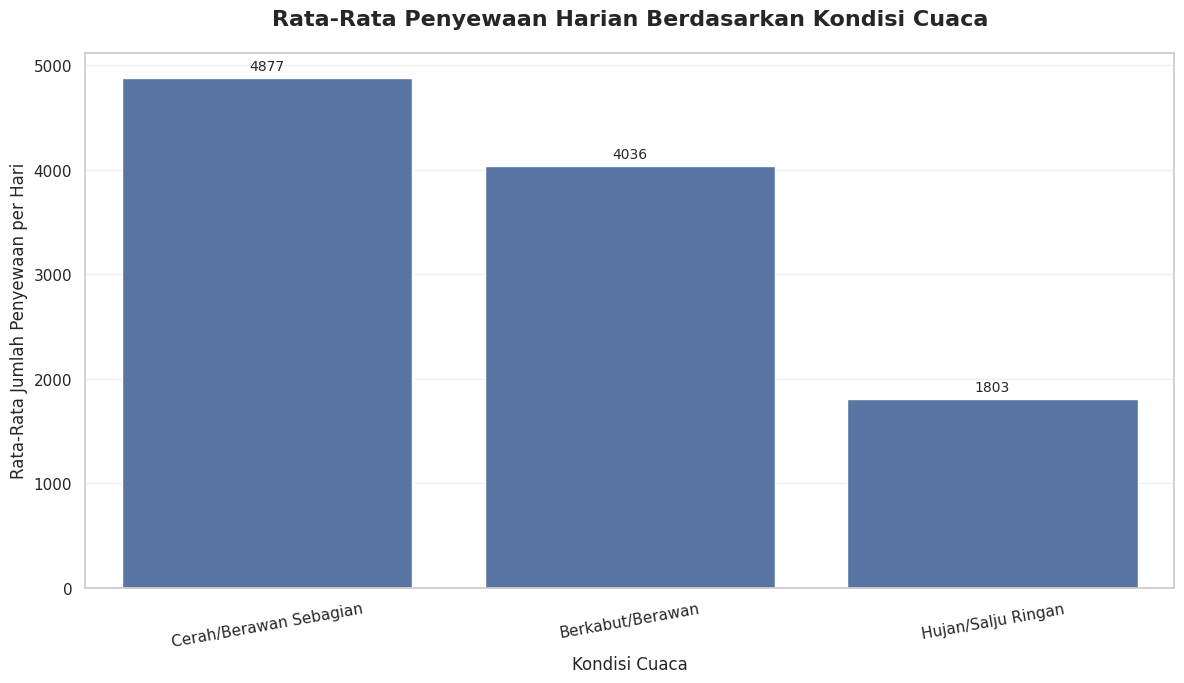

In [97]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=weather_summary,
    x="weather_label",
    y="average_total_rentals",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=10,
    )

plt.title(
    "Rata-Rata Penyewaan Harian Berdasarkan Kondisi Cuaca",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-Rata Jumlah Penyewaan per Hari")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

- Permintaan tertinggi terjadi pada cuaca cerah atau berawan sebagian.
- Permintaan mulai menurun pada kondisi berkabut atau berawan.
- Penurunan paling besar terjadi ketika terdapat hujan atau salju ringan.
- Tidak terdapat observasi harian dengan kategori hujan atau salju lebat pada `day.csv`.

#### Perbandingan Pengguna Casual dan Registered Berdasarkan Cuaca

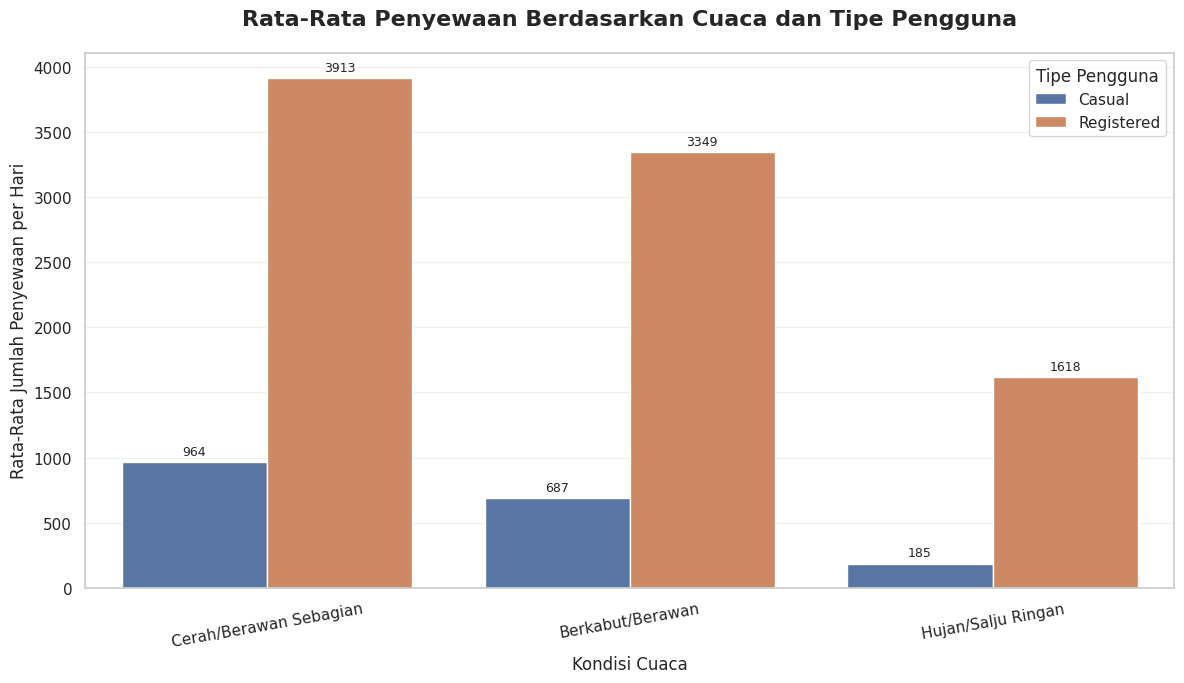

In [98]:
weather_user_long = weather_summary.melt(
    id_vars="weather_label",
    value_vars=[
        "average_casual_rentals",
        "average_registered_rentals",
    ],
    var_name="user_type",
    value_name="average_rentals",
)

weather_user_long["user_type"] = weather_user_long[
    "user_type"
].replace(
    {
        "average_casual_rentals": "Casual",
        "average_registered_rentals": "Registered",
    }
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=weather_user_long,
    x="weather_label",
    y="average_rentals",
    hue="user_type",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9,
    )

plt.title(
    "Rata-Rata Penyewaan Berdasarkan Cuaca dan Tipe Pengguna",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-Rata Jumlah Penyewaan per Hari")
plt.xticks(rotation=10)
plt.legend(title="Tipe Pengguna")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

- Pengguna registered tetap mendominasi jumlah penyewaan pada seluruh kondisi cuaca.
- Pengguna casual mengalami penurunan relatif yang lebih besar ketika kondisi cuaca memburuk.
- Dibandingkan cuaca cerah, penyewaan casual turun sekitar 80,8% ketika terjadi hujan atau salju ringan.
- Pada kondisi yang sama, penyewaan registered turun sekitar 58,7%.
- Temuan ini menunjukkan bahwa perjalanan pengguna registered kemungkinan lebih bersifat rutin, sedangkan perjalanan pengguna casual lebih mudah dibatalkan ketika cuaca memburuk.

## Analisis Lanjutan

Analisis lanjutan dilakukan menggunakan teknik **binning berbasis kuartil** tanpa algoritma machine learning.

Tujuannya adalah mengelompokkan setiap hari ke dalam empat tingkat permintaan:

1. Low
2. Medium
3. High
4. Very High

Pengelompokan ini dapat membantu pengelola menentukan strategi operasional berdasarkan karakteristik hari dengan permintaan rendah hingga sangat tinggi.

In [99]:
demand_labels = [
    "Low",
    "Medium",
    "High",
    "Very High",
]

day_clean["demand_level"] = pd.qcut(
    day_clean["cnt"],
    q=4,
    labels=demand_labels,
)

demand_distribution = (
    day_clean["demand_level"]
    .value_counts(sort=False)
    .rename_axis("demand_level")
    .reset_index(name="number_of_days")
)

display(demand_distribution)

,demand_level,number_of_days
0,Low,183
1,Medium,183
2,High,182
3,Very High,183


In [100]:
demand_profile = (
    day_clean.groupby(
        "demand_level",
        observed=False,
        as_index=False,
    )
    .agg(
        number_of_days=("cnt", "size"),
        average_rentals=("cnt", "mean"),
        minimum_rentals=("cnt", "min"),
        maximum_rentals=("cnt", "max"),
        average_temperature_c=("temp_c", "mean"),
        average_humidity_pct=("humidity_pct", "mean"),
        average_windspeed_kmh=("windspeed_kmh", "mean"),
    )
)

display(demand_profile.round(2))

,demand_level,number_of_days,average_rentals,minimum_rentals,maximum_rentals,average_temperature_c,average_humidity_pct,average_windspeed_kmh
0,Low,183,"1,933.58",22,3141,12.67,63.80,14.72
1,Medium,183,"3,916.65",3163,4548,20.03,64.89,12.77
2,High,182,"5,128.13",4549,5936,23.12,61.63,12.22
3,Very High,183,"7,042.45",5976,8714,25.44,60.84,11.33


### Visualisasi Segmentasi Tingkat Permintaan

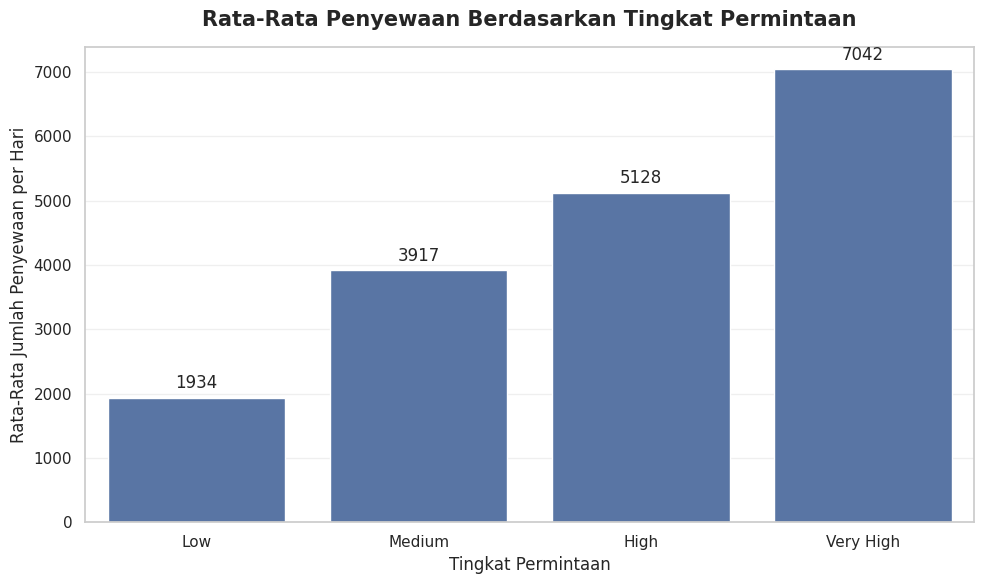

In [101]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=demand_profile,
    x="demand_level",
    y="average_rentals",
    order=demand_labels,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
    )

plt.title(
    "Rata-Rata Penyewaan Berdasarkan Tingkat Permintaan",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.xlabel("Tingkat Permintaan")
plt.ylabel("Rata-Rata Jumlah Penyewaan per Hari")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

- Kelompok `Low` memiliki rata-rata sekitar **1.934 penyewaan per hari**.
- Kelompok `Medium` memiliki rata-rata sekitar **3.917 penyewaan per hari**.
- Kelompok `High` memiliki rata-rata sekitar **5.128 penyewaan per hari**.
- Kelompok `Very High` memiliki rata-rata sekitar **7.042 penyewaan per hari**.
- Hari dengan permintaan `Very High` cenderung memiliki suhu lebih hangat, kelembapan lebih rendah, dan kecepatan angin lebih rendah dibandingkan kelompok `Low`.
- Segmentasi ini dapat digunakan sebagai dasar untuk menentukan tingkat kesiapan armada dan kebutuhan redistribusi sepeda.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Selama periode 2011–2012, pola penyewaan sepeda berbeda antara hari kerja dan non-hari kerja. Pada hari kerja, rata-rata penyewaan tertinggi terjadi pada pukul 17.00 dengan sekitar 525 penyewaan per jam. Permintaan tinggi juga terjadi pada pukul 08.00 dan 18.00, yang menunjukkan pola perjalanan komuter. Pada non-hari kerja, puncak penyewaan terjadi pada pukul 13.00 dengan sekitar 373 penyewaan per jam dan permintaan relatif tinggi berlangsung dari siang hingga sore.

- **Conclusion pertanyaan 2:** Kondisi cuaca memiliki hubungan yang kuat dengan jumlah penyewaan sepeda. Dibandingkan cuaca cerah atau berawan sebagian, rata-rata penyewaan turun sekitar 17,2% pada kondisi berkabut atau berawan dan turun sekitar 63,0% ketika terjadi hujan atau salju ringan. Pengguna casual menjadi kelompok yang paling sensitif terhadap perubahan cuaca. Pada hujan atau salju ringan, rata-rata pengguna casual turun sekitar 80,8%, sedangkan pengguna registered turun sekitar 58,7%.

- **Conclusion analisis lanjutan:** Segmentasi berbasis kuartil membagi hari menjadi empat tingkat permintaan. Kelompok `Very High` memiliki rata-rata sekitar 7.042 penyewaan per hari, sedangkan kelompok `Low` memiliki rata-rata sekitar 1.934 penyewaan per hari. Hari dengan permintaan sangat tinggi cenderung memiliki suhu lebih hangat, kelembapan lebih rendah, dan kecepatan angin lebih rendah.

## Conclusion & Recommendation

**Rekomendasi Action Item:**

- Pengelola perlu meningkatkan ketersediaan sepeda dan kapasitas docking station sebelum pukul 08.00 serta sebelum pukul 17.00 pada hari kerja.
- Proses redistribusi sepeda pada hari kerja sebaiknya dilakukan sebelum jam sibuk, bukan ketika permintaan sudah mencapai puncaknya.
- Pada non-hari kerja, ketersediaan sepeda perlu difokuskan pada periode pukul 11.00 hingga 16.00.
- Prakiraan cuaca sebaiknya dimasukkan ke dalam perencanaan operasional harian karena hujan atau salju ringan berkaitan dengan penurunan permintaan sekitar 63%.
- Ketika prakiraan cuaca buruk, pengelola dapat mengurangi redistribusi sepeda ke area wisata atau rekreasi yang banyak digunakan pengguna casual.
- Kapasitas minimum tetap perlu dipertahankan di area komuter karena pengguna registered lebih stabil dibandingkan pengguna casual ketika cuaca memburuk.
- Segmentasi `Low`, `Medium`, `High`, dan `Very High` dapat digunakan sebagai indikator sederhana untuk menentukan kebutuhan armada, petugas redistribusi, dan kapasitas docking station.

### Export Cleaned Data for Dashboard

Data hasil cleaning disimpan ke folder `dashboard` agar dapat digunakan oleh aplikasi Streamlit.

In [107]:
from pathlib import Path
import pandas as pd

DASHBOARD_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard"
)

DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

# Pastikan demand_level tersedia pada data harian
if "demand_level" not in day_clean.columns:
    day_clean["demand_level"] = pd.qcut(
        day_clean["cnt"],
        q=4,
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High",
        ],
    )

# Menandai jenis data
hour_dashboard = hour_clean.copy()
hour_dashboard["data_level"] = "hourly"

day_dashboard = day_clean.copy()
day_dashboard["data_level"] = "daily"

# day.csv tidak memiliki kolom jam
if "hr" not in day_dashboard.columns:
    day_dashboard["hr"] = pd.NA

# Menyamakan seluruh kolom sebelum digabungkan
all_columns = sorted(
    set(hour_dashboard.columns)
    | set(day_dashboard.columns)
)

hour_dashboard = hour_dashboard.reindex(
    columns=all_columns
)

day_dashboard = day_dashboard.reindex(
    columns=all_columns
)

main_data_df = pd.concat(
    [
        hour_dashboard,
        day_dashboard,
    ],
    ignore_index=True,
)

main_data_path = DASHBOARD_DIR / "main_data.csv"

main_data_df.to_csv(
    main_data_path,
    index=False,
)

print("main_data.csv berhasil dibuat")
print("Lokasi:", main_data_path)
print("Jumlah seluruh baris:", len(main_data_df))

print("\nDistribusi data:")
display(
    main_data_df["data_level"].value_counts()
)

/tmp/ipykernel_545/1941362698.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  main_data_df = pd.concat(


main_data.csv berhasil dibuat
Lokasi: /content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/main_data.csv
Jumlah seluruh baris: 18110

Distribusi data:


,count
data_level,
hourly,17379
daily,731


In [108]:
from pathlib import Path

day_data_path = Path(
    "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/day_data.csv"
)

if day_data_path.exists():
    day_data_path.unlink()
    print("day_data.csv berhasil dihapus")
else:
    print("day_data.csv sudah tidak ada")

day_data.csv sudah tidak ada


# dashboard.py

In [104]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/dashboard.py"

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import streamlit as st


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Bike Sharing Dashboard",
    page_icon="🚲",
    layout="wide",
    initial_sidebar_state="expanded",
)

sns.set_theme(style="whitegrid")


# =========================================================
# CUSTOM STYLE
# =========================================================

st.markdown(
    """
    <style>
        .block-container {
            padding-top: 2rem;
            padding-bottom: 3rem;
        }

        div[data-testid="stMetric"] {
            background-color: rgba(128, 128, 128, 0.08);
            border: 1px solid rgba(128, 128, 128, 0.20);
            padding: 16px;
            border-radius: 12px;
        }

        .dashboard-description {
            font-size: 1rem;
            line-height: 1.6;
            margin-bottom: 1rem;
        }

        .insight-box {
            background-color: rgba(128, 128, 128, 0.08);
            border-left: 5px solid #888888;
            padding: 16px;
            border-radius: 8px;
            margin-top: 10px;
            margin-bottom: 20px;
        }
    </style>
    """,
    unsafe_allow_html=True,
)


# =========================================================
# DATA LOADING
# =========================================================

BASE_DIR = Path(__file__).resolve().parent

HOURLY_DATA_PATH = BASE_DIR / "main_data.csv"
DAILY_DATA_PATH = BASE_DIR / "day_data.csv"


@st.cache_data
def load_data():
    """Memuat dan mempersiapkan dataset dashboard."""

    if not HOURLY_DATA_PATH.exists():
        raise FileNotFoundError(
            f"File tidak ditemukan: {HOURLY_DATA_PATH}"
        )

    if not DAILY_DATA_PATH.exists():
        raise FileNotFoundError(
            f"File tidak ditemukan: {DAILY_DATA_PATH}"
        )

    hourly_dataframe = pd.read_csv(
        HOURLY_DATA_PATH,
        parse_dates=["dteday"],
    )

    daily_dataframe = pd.read_csv(
        DAILY_DATA_PATH,
        parse_dates=["dteday"],
    )

    return hourly_dataframe, daily_dataframe


try:
    hour_df, day_df = load_data()
except Exception as error:
    st.error(f"Gagal memuat dataset: {error}")
    st.stop()


# =========================================================
# DATA VALIDATION
# =========================================================

required_hour_columns = {
    "dteday",
    "hr",
    "day_type",
    "weather_label",
    "casual",
    "registered",
    "cnt",
}

required_day_columns = {
    "dteday",
    "day_type",
    "weather_label",
    "casual",
    "registered",
    "cnt",
    "temp_c",
    "humidity_pct",
    "windspeed_kmh",
}

missing_hour_columns = required_hour_columns.difference(
    hour_df.columns
)

missing_day_columns = required_day_columns.difference(
    day_df.columns
)

if missing_hour_columns:
    st.error(
        "Kolom berikut tidak ditemukan pada main_data.csv: "
        + ", ".join(sorted(missing_hour_columns))
    )
    st.stop()

if missing_day_columns:
    st.error(
        "Kolom berikut tidak ditemukan pada day_data.csv: "
        + ", ".join(sorted(missing_day_columns))
    )
    st.stop()


# Membuat demand level apabila belum tersedia
if "demand_level" not in day_df.columns:
    demand_labels = [
        "Low",
        "Medium",
        "High",
        "Very High",
    ]

    day_df["demand_level"] = pd.qcut(
        day_df["cnt"],
        q=4,
        labels=demand_labels,
    )


# =========================================================
# HEADER
# =========================================================

st.title("🚲 Bike Sharing Data Analysis Dashboard")

st.markdown(
    """
    <div class="dashboard-description">
        Dashboard ini menampilkan pola penyewaan sepeda pada
        Capital Bikeshare selama periode 2011–2012.
        Analisis difokuskan pada perbedaan jam sibuk antara hari
        kerja dan non-hari kerja serta hubungan kondisi cuaca
        dengan jumlah penyewaan.
    </div>
    """,
    unsafe_allow_html=True,
)


# =========================================================
# SIDEBAR FILTER
# =========================================================

st.sidebar.header("Filter Dashboard")

minimum_date = day_df["dteday"].min().date()
maximum_date = day_df["dteday"].max().date()

selected_dates = st.sidebar.date_input(
    label="Rentang Tanggal",
    value=(minimum_date, maximum_date),
    min_value=minimum_date,
    max_value=maximum_date,
)

if isinstance(selected_dates, (tuple, list)):
    if len(selected_dates) == 2:
        start_date = pd.Timestamp(selected_dates[0])
        end_date = pd.Timestamp(selected_dates[1])
    elif len(selected_dates) == 1:
        start_date = pd.Timestamp(selected_dates[0])
        end_date = pd.Timestamp(selected_dates[0])
    else:
        start_date = pd.Timestamp(minimum_date)
        end_date = pd.Timestamp(maximum_date)
else:
    start_date = pd.Timestamp(selected_dates)
    end_date = pd.Timestamp(selected_dates)


day_type_options = sorted(
    day_df["day_type"].dropna().unique().tolist()
)

selected_day_types = st.sidebar.multiselect(
    label="Jenis Hari",
    options=day_type_options,
    default=day_type_options,
)


weather_options = sorted(
    day_df["weather_label"].dropna().unique().tolist()
)

selected_weather = st.sidebar.multiselect(
    label="Kondisi Cuaca",
    options=weather_options,
    default=weather_options,
)


st.sidebar.markdown("---")

st.sidebar.caption(
    "Gunakan filter untuk melihat perubahan pola penyewaan "
    "berdasarkan tanggal, jenis hari, dan kondisi cuaca."
)


# =========================================================
# APPLY FILTER
# =========================================================

day_filter_mask = (
    day_df["dteday"].between(start_date, end_date)
    & day_df["day_type"].isin(selected_day_types)
    & day_df["weather_label"].isin(selected_weather)
)

hour_filter_mask = (
    hour_df["dteday"].between(start_date, end_date)
    & hour_df["day_type"].isin(selected_day_types)
    & hour_df["weather_label"].isin(selected_weather)
)

filtered_day_df = day_df.loc[day_filter_mask].copy()
filtered_hour_df = hour_df.loc[hour_filter_mask].copy()


if filtered_day_df.empty or filtered_hour_df.empty:
    st.warning(
        "Tidak ada data yang sesuai dengan kombinasi filter. "
        "Silakan ubah rentang tanggal atau pilihan kategori."
    )
    st.stop()


# =========================================================
# SUMMARY METRICS
# =========================================================

total_rentals = int(filtered_day_df["cnt"].sum())

average_daily_rentals = filtered_day_df["cnt"].mean()

total_casual = int(filtered_day_df["casual"].sum())

total_registered = int(filtered_day_df["registered"].sum())

registered_share = (
    total_registered / total_rentals * 100
    if total_rentals > 0
    else 0
)

hourly_average = (
    filtered_hour_df.groupby(
        "hr",
        as_index=False,
    )
    .agg(
        average_rentals=("cnt", "mean")
    )
)

peak_hour_row = hourly_average.loc[
    hourly_average["average_rentals"].idxmax()
]

peak_hour = int(peak_hour_row["hr"])
peak_hour_average = peak_hour_row["average_rentals"]


st.subheader("Ringkasan Penyewaan")

metric_column_1, metric_column_2, metric_column_3, metric_column_4 = (
    st.columns(4)
)

with metric_column_1:
    st.metric(
        label="Total Penyewaan",
        value=f"{total_rentals:,}",
    )

with metric_column_2:
    st.metric(
        label="Rata-Rata Harian",
        value=f"{average_daily_rentals:,.0f}",
    )

with metric_column_3:
    st.metric(
        label="Jam Puncak",
        value=f"{peak_hour:02d}.00",
        delta=f"{peak_hour_average:,.0f} rata-rata/jam",
        delta_color="off",
    )

with metric_column_4:
    st.metric(
        label="Kontribusi Registered",
        value=f"{registered_share:.1f}%",
    )


st.caption(
    f"Data yang ditampilkan mencakup "
    f"{filtered_day_df['dteday'].nunique():,} hari, "
    f"mulai {start_date.strftime('%d %B %Y')} sampai "
    f"{end_date.strftime('%d %B %Y')}."
)


# =========================================================
# DAILY TREND
# =========================================================

st.markdown("---")
st.subheader("Tren Penyewaan Harian")

daily_trend = (
    filtered_day_df.groupby(
        "dteday",
        as_index=False,
    )
    .agg(
        total_rentals=("cnt", "sum")
    )
    .sort_values("dteday")
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=daily_trend,
    x="dteday",
    y="total_rentals",
    ax=ax,
    linewidth=1.8,
)

ax.set_title(
    "Perkembangan Jumlah Penyewaan Sepeda",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah Penyewaan")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

st.pyplot(fig)
plt.close(fig)


# =========================================================
# BUSINESS QUESTION 1
# =========================================================

st.markdown("---")
st.header("Pertanyaan Bisnis 1")

st.markdown(
    """
    **Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai
    nilai tertinggi pada hari kerja dan non-hari kerja?**
    """
)

hourly_pattern = (
    filtered_hour_df.groupby(
        ["day_type", "hr"],
        as_index=False,
    )
    .agg(
        average_total_rentals=("cnt", "mean"),
        average_casual_rentals=("casual", "mean"),
        average_registered_rentals=("registered", "mean"),
    )
)

peak_by_day_type = hourly_pattern.loc[
    hourly_pattern.groupby("day_type")[
        "average_total_rentals"
    ].idxmax()
].copy()


fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=hourly_pattern,
    x="hr",
    y="average_total_rentals",
    hue="day_type",
    marker="o",
    linewidth=2.3,
    ax=ax,
)

for _, peak_row in peak_by_day_type.iterrows():
    ax.scatter(
        peak_row["hr"],
        peak_row["average_total_rentals"],
        s=110,
        zorder=5,
    )

    ax.annotate(
        (
            f'{peak_row["day_type"]}\n'
            f'{int(peak_row["hr"]):02d}.00\n'
            f'{peak_row["average_total_rentals"]:.0f}'
        ),
        xy=(
            peak_row["hr"],
            peak_row["average_total_rentals"],
        ),
        xytext=(0, 18),
        textcoords="offset points",
        ha="center",
        fontweight="bold",
    )

ax.set_title(
    "Rata-Rata Penyewaan Berdasarkan Jam dan Jenis Hari",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Jam")
ax.set_ylabel("Rata-Rata Jumlah Penyewaan")
ax.set_xticks(range(0, 24))
ax.legend(title="Jenis Hari")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

st.pyplot(fig)
plt.close(fig)


peak_insights = []

for _, peak_row in peak_by_day_type.sort_values(
    "day_type"
).iterrows():
    peak_insights.append(
        f"""
        - **{peak_row['day_type']}** mencapai rata-rata penyewaan
          tertinggi pada pukul **{int(peak_row['hr']):02d}.00**
          dengan sekitar
          **{peak_row['average_total_rentals']:,.0f} penyewaan
          per jam**.
        """
    )

st.markdown(
    f"""
    <div class="insight-box">
        <strong>Insight:</strong><br>
        {"".join(peak_insights)}
        Pola jam puncak yang berbeda menunjukkan bahwa pengelola
        perlu menerapkan strategi redistribusi sepeda yang berbeda
        antara hari kerja dan non-hari kerja.
    </div>
    """,
    unsafe_allow_html=True,
)


# =========================================================
# BUSINESS QUESTION 2
# =========================================================

st.markdown("---")
st.header("Pertanyaan Bisnis 2")

st.markdown(
    """
    **Seberapa besar perbedaan rata-rata penyewaan pada setiap
    kondisi cuaca dan kelompok pengguna mana yang paling sensitif
    terhadap perubahan cuaca?**
    """
)

weather_summary = (
    filtered_day_df.groupby(
        "weather_label",
        as_index=False,
    )
    .agg(
        average_total_rentals=("cnt", "mean"),
        average_casual_rentals=("casual", "mean"),
        average_registered_rentals=("registered", "mean"),
        number_of_days=("cnt", "size"),
    )
    .sort_values(
        "average_total_rentals",
        ascending=False,
    )
)


weather_column_1, weather_column_2 = st.columns(2)


with weather_column_1:
    st.subheader("Total Penyewaan Berdasarkan Cuaca")

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.barplot(
        data=weather_summary,
        x="weather_label",
        y="average_total_rentals",
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
        )

    ax.set_title(
        "Rata-Rata Penyewaan Harian",
        fontweight="bold",
    )

    ax.set_xlabel("Kondisi Cuaca")
    ax.set_ylabel("Rata-Rata Penyewaan")
    ax.tick_params(
        axis="x",
        rotation=20,
    )
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    st.pyplot(fig)
    plt.close(fig)


with weather_column_2:
    st.subheader("Casual dan Registered")

    weather_user_long = weather_summary.melt(
        id_vars="weather_label",
        value_vars=[
            "average_casual_rentals",
            "average_registered_rentals",
        ],
        var_name="user_type",
        value_name="average_rentals",
    )

    weather_user_long["user_type"] = (
        weather_user_long["user_type"].replace(
            {
                "average_casual_rentals": "Casual",
                "average_registered_rentals": "Registered",
            }
        )
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.barplot(
        data=weather_user_long,
        x="weather_label",
        y="average_rentals",
        hue="user_type",
        ax=ax,
    )

    ax.set_title(
        "Rata-Rata Berdasarkan Tipe Pengguna",
        fontweight="bold",
    )

    ax.set_xlabel("Kondisi Cuaca")
    ax.set_ylabel("Rata-Rata Penyewaan")
    ax.tick_params(
        axis="x",
        rotation=20,
    )
    ax.legend(title="Tipe Pengguna")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    st.pyplot(fig)
    plt.close(fig)


if len(weather_summary) > 1:
    best_weather = weather_summary.iloc[0]
    worst_weather = weather_summary.iloc[-1]

    total_decline = (
        1
        - worst_weather["average_total_rentals"]
        / best_weather["average_total_rentals"]
    ) * 100

    casual_decline = (
        1
        - worst_weather["average_casual_rentals"]
        / best_weather["average_casual_rentals"]
    ) * 100

    registered_decline = (
        1
        - worst_weather["average_registered_rentals"]
        / best_weather["average_registered_rentals"]
    ) * 100

    sensitive_user = (
        "casual"
        if casual_decline > registered_decline
        else "registered"
    )

    st.markdown(
        f"""
        <div class="insight-box">
            <strong>Insight:</strong><br>
            Kondisi dengan rata-rata penyewaan tertinggi adalah
            <strong>{best_weather["weather_label"]}</strong>,
            sedangkan kondisi dengan rata-rata terendah adalah
            <strong>{worst_weather["weather_label"]}</strong>.
            Perbedaan rata-rata penyewaan antara kedua kondisi
            tersebut mencapai sekitar
            <strong>{total_decline:.1f}%</strong>.<br><br>

            Pengguna <strong>{sensitive_user}</strong> menjadi
            kelompok yang lebih sensitif terhadap perubahan cuaca.
            Penurunan pengguna casual mencapai sekitar
            <strong>{casual_decline:.1f}%</strong>, sedangkan
            pengguna registered turun sekitar
            <strong>{registered_decline:.1f}%</strong>.
        </div>
        """,
        unsafe_allow_html=True,
    )
else:
    st.info(
        "Pilih lebih dari satu kondisi cuaca untuk membandingkan "
        "besarnya perubahan penyewaan."
    )


# =========================================================
# USER COMPOSITION
# =========================================================

st.markdown("---")
st.subheader("Komposisi Pengguna")

user_composition = pd.DataFrame(
    {
        "user_type": [
            "Casual",
            "Registered",
        ],
        "total_rentals": [
            total_casual,
            total_registered,
        ],
    }
)

user_column_1, user_column_2 = st.columns([1, 1])


with user_column_1:
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.pie(
        user_composition["total_rentals"],
        labels=user_composition["user_type"],
        autopct="%1.1f%%",
        startangle=90,
    )

    ax.set_title(
        "Proporsi Tipe Pengguna",
        fontweight="bold",
    )

    fig.tight_layout()

    st.pyplot(fig)
    plt.close(fig)


with user_column_2:
    st.dataframe(
        user_composition.rename(
            columns={
                "user_type": "Tipe Pengguna",
                "total_rentals": "Total Penyewaan",
            }
        ),
        hide_index=True,
        use_container_width=True,
    )

    st.markdown(
        f"""
        Pengguna registered menyumbang sekitar
        **{registered_share:.1f}%** dari seluruh penyewaan pada
        periode yang dipilih.
        """
    )


# =========================================================
# ADVANCED ANALYSIS
# =========================================================

st.markdown("---")
st.header("Analisis Lanjutan")

st.markdown(
    """
    Segmentasi permintaan menggunakan teknik binning berbasis
    kuartil. Setiap hari dikelompokkan menjadi `Low`, `Medium`,
    `High`, atau `Very High` tanpa menggunakan algoritma
    machine learning.
    """
)

demand_order = [
    "Low",
    "Medium",
    "High",
    "Very High",
]

demand_profile = (
    filtered_day_df.groupby(
        "demand_level",
        observed=False,
        as_index=False,
    )
    .agg(
        number_of_days=("cnt", "size"),
        average_rentals=("cnt", "mean"),
        average_temperature_c=("temp_c", "mean"),
        average_humidity_pct=("humidity_pct", "mean"),
        average_windspeed_kmh=("windspeed_kmh", "mean"),
    )
)

demand_profile["demand_level"] = pd.Categorical(
    demand_profile["demand_level"],
    categories=demand_order,
    ordered=True,
)

demand_profile = demand_profile.sort_values(
    "demand_level"
)


advanced_column_1, advanced_column_2 = st.columns(
    [1.2, 1]
)


with advanced_column_1:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=demand_profile,
        x="demand_level",
        y="average_rentals",
        order=demand_order,
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
        )

    ax.set_title(
        "Rata-Rata Penyewaan per Tingkat Permintaan",
        fontweight="bold",
    )

    ax.set_xlabel("Tingkat Permintaan")
    ax.set_ylabel("Rata-Rata Penyewaan")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    st.pyplot(fig)
    plt.close(fig)


with advanced_column_2:
    display_demand_profile = demand_profile.copy()

    display_demand_profile = display_demand_profile.rename(
        columns={
            "demand_level": "Tingkat Permintaan",
            "number_of_days": "Jumlah Hari",
            "average_rentals": "Rata-Rata Penyewaan",
            "average_temperature_c": "Suhu Rata-Rata",
            "average_humidity_pct": "Kelembapan Rata-Rata",
            "average_windspeed_kmh": "Angin Rata-Rata",
        }
    )

    st.dataframe(
        display_demand_profile.round(2),
        hide_index=True,
        use_container_width=True,
    )


# =========================================================
# RECOMMENDATION
# =========================================================

st.markdown("---")
st.header("Conclusion & Recommendation")

st.markdown(
    """
    **Rekomendasi Action Item:**

    1. Pengelola perlu menyiapkan sepeda dan kapasitas docking
       station sebelum jam sibuk hari kerja.

    2. Pada non-hari kerja, ketersediaan sepeda perlu difokuskan
       dari siang hingga sore.

    3. Prakiraan cuaca sebaiknya digunakan dalam perencanaan
       redistribusi sepeda harian.

    4. Saat cuaca buruk diperkirakan terjadi, redistribusi ke
       lokasi wisata atau rekreasi dapat dikurangi karena pengguna
       casual lebih sensitif terhadap cuaca.

    5. Kapasitas minimum tetap perlu dipertahankan pada area
       komuter karena pengguna registered memiliki pola penggunaan
       yang lebih stabil.

    6. Segmentasi tingkat permintaan dapat digunakan untuk
       menentukan kebutuhan armada dan petugas operasional.
    """
)


# =========================================================
# DOWNLOAD FILTERED DATA
# =========================================================

st.markdown("---")
st.subheader("Unduh Data")

download_column_1, download_column_2 = st.columns(2)

with download_column_1:
    st.download_button(
        label="Unduh Data Harian",
        data=filtered_day_df.to_csv(index=False).encode("utf-8"),
        file_name="filtered_day_data.csv",
        mime="text/csv",
        use_container_width=True,
    )

with download_column_2:
    st.download_button(
        label="Unduh Data Per Jam",
        data=filtered_hour_df.to_csv(index=False).encode("utf-8"),
        file_name="filtered_hour_data.csv",
        mime="text/csv",
        use_container_width=True,
    )


st.markdown("---")

st.caption(
    "Bike Sharing Dashboard | Dataset Capital Bikeshare 2011–2012"
)

Writing /content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/dashboard.py


In [105]:
from pathlib import Path

dashboard_path = Path(
    "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/dashboard.py"
)

print("File ditemukan:", dashboard_path.exists())
print("Ukuran file:", dashboard_path.stat().st_size if dashboard_path.exists() else 0)
print("Lokasi:", dashboard_path)

File ditemukan: True
Ukuran file: 21719
Lokasi: /content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/dashboard.py


In [106]:
!python -m py_compile "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/dashboard.py"

In [109]:
!python -m py_compile "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard/dashboard.py"

In [110]:
from pathlib import Path

dashboard_dir = Path(
    "/content/drive/MyDrive/Colab Notebooks/Submission Fundamental Data/dashboard"
)

for file_path in dashboard_dir.iterdir():
    print(
        file_path.name,
        f"{file_path.stat().st_size:,} bytes"
    )

main_data.csv 2,988,402 bytes
.ipynb_checkpoints 4,096 bytes
dashboard.py 22,672 bytes
__pycache__ 4,096 bytes


# Install Streamlit


In [111]:
!pip -q install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.7 MB/s eta 0:00:00


In [112]:
import subprocess
import time
import urllib.request

APP_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Submission Fundamental Data/dashboard/dashboard.py"
)

streamlit_process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        APP_PATH,
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

for attempt in range(30):
    try:
        response = urllib.request.urlopen(
            "http://127.0.0.1:8501/_stcore/health",
            timeout=2,
        )

        if response.status == 200:
            print("Streamlit aktif")
            break
    except Exception:
        time.sleep(1)

Streamlit aktif


# Buka Ngrok

In [113]:
from getpass import getpass
from pyngrok import ngrok

ngrok_token = getpass("Masukkan ngrok authtoken: ")

ngrok.set_auth_token(ngrok_token)
ngrok.kill()

public_url = ngrok.connect(8501).public_url

print("Dashboard URL:")
print(public_url)

Masukkan ngrok authtoken: ··········
Dashboard URL:
https://essay-crowbar-evaporate.ngrok-free.dev
